In [2]:
from pathlib import Path
import pandas as pd
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import evaluate_finetuned_model
from sklearn.metrics import classification_report

In [3]:
# Dataset Parameters
composite_window="month"
unique_id_column="Field_ID"
data_folder = Path.cwd().parent / f"data/extractions/{composite_window}"

In [4]:
ref_id = 'Maize_2021_5mbuffered'
extractions_2021 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2021-07-01", "2021-11-30"],
)
ref_id = 'Maize_2022_5mbuffered'
extractions_2022 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2022-07-01", "2022-11-30"],
)
ref_id = 'Maize_2023_5mbuffered'
extractions_2023 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2023-07-01", "2023-11-30"],
)
ref_id = 'tamale_30field_2025_5mbuffer'
extractions_2025 = load_dataset(
    str(Path(data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=5,
    window_of_interest=["2025-07-01", "2025-11-30"],
)

  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:744: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["start_date"] = window_of_interest[0]
/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["end_date"] = window_of_interest[1]
  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/

#### Data investigation

In [5]:
# Print min and max of yield distribution for each year
th = 65535
extractions_2022 = extractions_2022[extractions_2022['Yield kg/H'] != th].reset_index(drop=True)
datasets = [extractions_2021, extractions_2022, extractions_2023, extractions_2025]
years = [2021, 2022, 2023, 2025]

for i, (dataset, year) in enumerate(zip(datasets, years)):
    min_yield = dataset['Yield kg/H'].min()
    max_yield = dataset['Yield kg/H'].max()
    print(f"Year {year}: Min = {min_yield:.2f} kg/H, Max = {max_yield:.2f} kg/H")


Year 2021: Min = 190.70 kg/H, Max = 3446.10 kg/H
Year 2022: Min = 226.60 kg/H, Max = 4792.60 kg/H
Year 2023: Min = 901.10 kg/H, Max = 6352.20 kg/H
Year 2025: Min = 785.55 kg/H, Max = 2830.45 kg/H


In [6]:
for y in years:
    datasets[years.index(y)]['year'] = y
extractions = pd.concat(datasets, ignore_index=True)
target_column = "Yield kg/H"
extractions["Field_ID_year"] = extractions['Field_ID'] + "_" + extractions['year'].astype(str)
extractions['REGION'] = extractions['REGION'].apply(lambda x: 'Northern' if x != 'Savanna' else 'Savanna')
extractions['DISTRICT'] = extractions['DISTRICT'].apply(lambda x: x.split('\n')[0].upper())
extractions['COMMUNITY'] = extractions['COMMUNITY'].apply(lambda x: x.upper())
extractions[unique_id_column] = extractions[unique_id_column].astype(str) + "_" + extractions['year'].astype(str)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_distribution(train_df, test_df, val_df, target_column):
    # Create a figure with subplots for the value counts including train/test/val splits
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distribution of Variables by Train/Test/Validation Split', fontsize=16)

    # Define colors for train/test/val
    colors = ['blue', 'orange', 'green']
    labels = ['Train', 'Test', 'Val']
    datasets = [train_df, test_df, val_df]

    # REGION distribution
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        region_counts = data.REGION.value_counts()
        axes[0, 0].bar(region_counts.index, region_counts.values, alpha=0.7, color=color, label=label)
    axes[0, 0].set_title('REGION')
    axes[0, 0].set_xlabel('Region')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    # COMMUNITY distribution
    all_communities = pd.concat(datasets).COMMUNITY.unique()
    x_pos = range(len(all_communities))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        community_counts = data.COMMUNITY.value_counts().reindex(all_communities, fill_value=0)
        axes[0, 1].bar([x + i*0.25 for x in x_pos], community_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[0, 1].set_title('COMMUNITY')
    axes[0, 1].set_xlabel('Community')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xticks([x + 0.25 for x in x_pos])
    axes[0, 1].set_xticklabels(all_communities, rotation=45, ha='right')
    axes[0, 1].legend()

    # DISTRICT distribution
    all_districts = pd.concat(datasets).DISTRICT.unique()
    x_pos_district = range(len(all_districts))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        district_counts = data.DISTRICT.value_counts().reindex(all_districts, fill_value=0)
        axes[1, 0].bar([x + i*0.25 for x in x_pos_district], district_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 0].set_title('DISTRICT')
    axes[1, 0].set_xlabel('District')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticks([x + 0.25 for x in x_pos_district])
    axes[1, 0].set_xticklabels(all_districts, rotation=45, ha='right')
    axes[1, 0].legend()

    # YEAR distribution
    all_years = sorted(pd.concat(datasets).year.unique())
    x_pos_year = range(len(all_years))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        year_counts = data.year.value_counts().reindex(all_years, fill_value=0)
        axes[1, 1].bar([x + i*0.25 for x in x_pos_year], year_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 1].set_title('YEAR')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xticks([x + 0.25 for x in x_pos_year])
    axes[1, 1].set_xticklabels(all_years)
    axes[1, 1].legend()

    # Yield kg/H histogram with bars next to each other
    bin_edges = np.histogram_bin_edges(
        pd.concat([train_df[target_column], test_df[target_column], val_df[target_column]]).dropna(), bins=20
    )

    width = 0.25
    # Plot histogram for Yield kg/H for each split using the same bin edges
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        hist, _ = np.histogram(data[target_column].dropna(), bins=bin_edges)
        # Use bin centers for bar positions
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        axes[0, 2].bar(bin_centers + i*width - width, hist, width=width, alpha=0.7, color=color, label=label, align='center')
    axes[0, 2].set_title('Yield kg/H')
    axes[0, 2].set_xlabel('Yield kg/H')
    axes[0, 2].set_xticklabels(['', '', 'Low', '', '', '', 'High', ''])
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()

    # Bin mean yield and std plot
    bin_labels = ['Low', 'High'] if 'bin' in train_df.columns else train_df['bin'].unique().astype(str)
    x = np.arange(len(bin_labels))
    for idx, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        bin_means = data.groupby('bin')['Yield kg/H'].mean().reindex([0,1], fill_value=0)
        bin_stds = data.groupby('bin')['Yield kg/H'].std().reindex([0,1], fill_value=0)
        axes[1, 2].bar(x + idx*width, bin_means.values, width=width, yerr=bin_stds.values, capsize=5, color=color, alpha=0.8, label=label)

    axes[1, 2].set_title('Bin Mean Yield ± Std')
    axes[1, 2].set_xlabel('Bin')
    axes[1, 2].set_ylabel('Mean Yield (kg/H)')
    axes[1, 2].set_xticks(x + width)
    axes[1, 2].set_xticklabels(bin_labels)
    axes[1, 2].legend()
    # # Remove the empty subplot
    # axes[1, 2].remove()

    plt.tight_layout()
    plt.show()

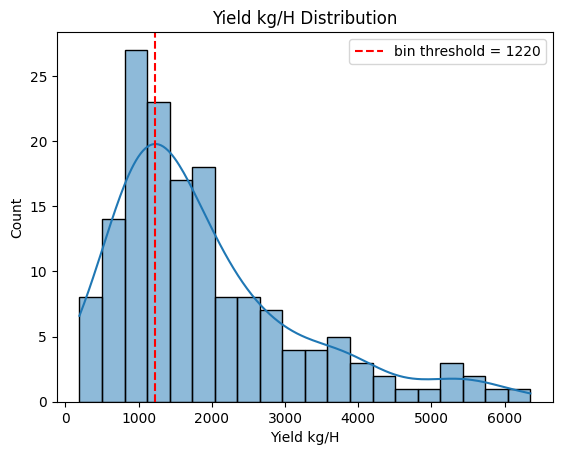

In [8]:
import seaborn as sns
bin_th = 1220
sns.histplot(extractions['Yield kg/H'], bins=20, kde=True)
plt.axvline(bin_th, color='red', linestyle='--', label=f"bin threshold = {str(bin_th)}")
plt.title('Yield kg/H Distribution')
plt.legend()
plt.show()

### Binarize target

In [9]:
from sklearn.model_selection import train_test_split

# Create bins for stratification based on the parent group's median yield
extractions['bin'] = extractions[target_column].apply(lambda x: 0 if x < bin_th else 1)

# Filter out yield bins with less than 3 samples to avoid stratification issues
bin_counts = extractions['bin'].value_counts()
valid_bins = bin_counts[bin_counts >= 3].index
extractions_filtered = extractions[extractions['bin'].isin(valid_bins)]

# Compute mean and std of yield for each bin and add as columns
bin_stats = extractions_filtered.groupby('bin')[target_column].agg(['mean', 'std']).rename(columns={'mean': 'bin_mean_yield', 'std': 'bin_std_yield'})
extractions_filtered = extractions_filtered.merge(bin_stats, left_on='bin', right_index=True, how='left')

print(f"Original parent groups: {len(extractions)}")
print(f"After filtering bins with <3 samples: {len(extractions_filtered)}")
print(f"Removed {len(extractions) - len(extractions_filtered)} parent groups")

# Get unique parentnames as our splitting units (from filtered data)
parentnames = extractions_filtered[unique_id_column].unique().tolist()
yield_bins = extractions_filtered['bin'].values

# First split: 80% train, 20% temp (for val and test)
train_parents, temp_parents = train_test_split(
    parentnames,
    train_size=0.8,
    stratify=yield_bins,
    random_state=42
)

# Get yield bins for temp parents and check if they still have enough samples for stratification
temp_bins = extractions_filtered[extractions_filtered[unique_id_column].isin(temp_parents)]['bin'].values
temp_bin_counts = pd.Series(temp_bins).value_counts()

# Check if any bin in temp set has less than 2 samples (minimum for stratification)
if (temp_bin_counts < 2).any():
    print("Warning: Some bins in temp set have <2 samples. Using random split instead of stratified split for val/test.")
    # Second split: split temp randomly into 50-50 for val and test
    val_parents, test_parents = train_test_split(
        temp_parents,
        train_size=0.5,
        random_state=42
    )
else:
    # Second split: split temp into 50-50 for val and test with stratification
    val_parents, test_parents = train_test_split(
        temp_parents,
        train_size=0.5,
        stratify=temp_bins,
        random_state=42
    )

# Create the final datasets by filtering on parentname
train_df = extractions_filtered[extractions_filtered[unique_id_column].isin(train_parents)]
val_df = extractions_filtered[extractions_filtered[unique_id_column].isin(val_parents)]
test_df = extractions_filtered[extractions_filtered[unique_id_column].isin(test_parents)]

print(f"Train set size: {len(train_df)} ({len(train_df)/len(extractions_filtered)*100:.1f}%)")
print(f"Validation set size: {len(val_df)} ({len(val_df)/len(extractions_filtered)*100:.1f}%)")
print(f"Test set size: {len(test_df)} ({len(test_df)/len(extractions_filtered)*100:.1f}%)")

# Verify no parentname overlap
assert len(set(train_df[unique_id_column]) & set(val_df[unique_id_column])) == 0
assert len(set(train_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
assert len(set(val_df[unique_id_column]) & set(test_df[unique_id_column])) == 0
print(f"✓ No {unique_id_column} overlap between splits")

Original parent groups: 157
After filtering bins with <3 samples: 157
Removed 0 parent groups
Train set size: 125 (79.6%)
Validation set size: 16 (10.2%)
Test set size: 16 (10.2%)
✓ No Field_ID overlap between splits


/tmp/ipykernel_3440458/529029868.py:76: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0, 2].set_xticklabels(['', '', 'Low', '', '', '', 'High', ''])


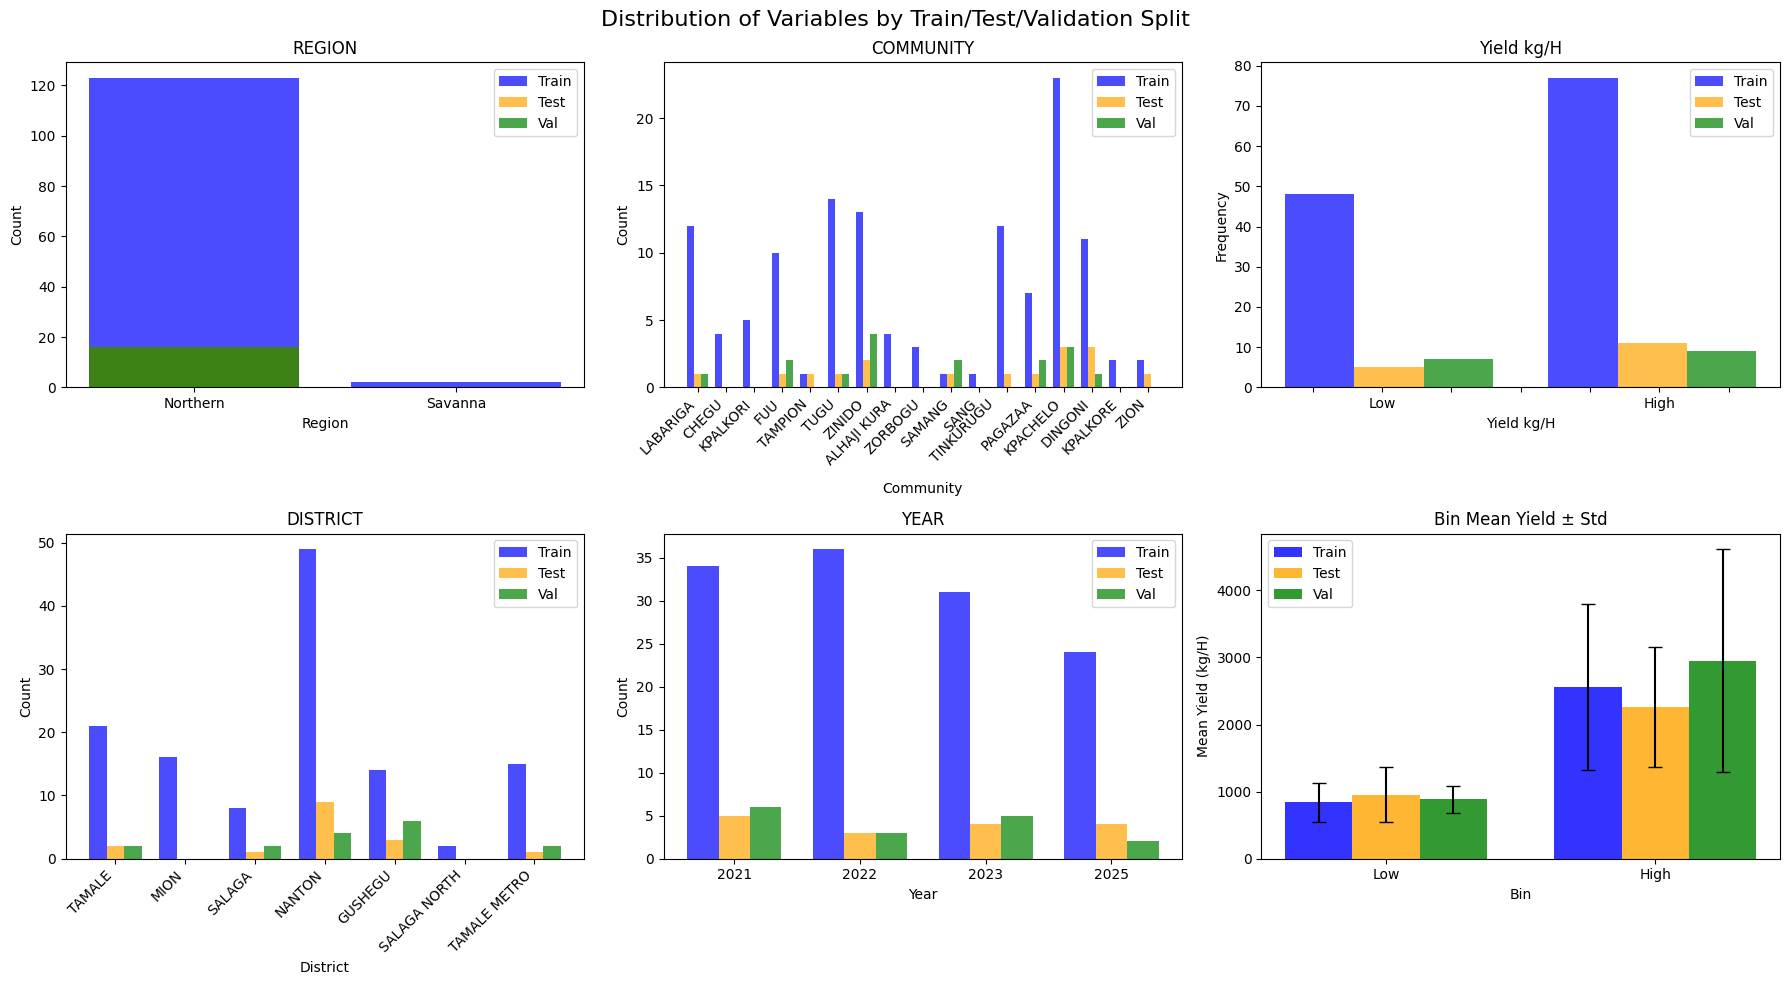

In [9]:
plot_distribution(train_df, test_df, val_df, 'bin')

##### Random Forest

In [10]:
target_column = 'bin'
# predict mean and evaluate based on std 

In [11]:
s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [12]:
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

In [13]:
import numpy as np 

X_train = X_train.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestClassifier(
        n_estimators=10,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        oob_score=True,
        warm_start=True
    ))
])

# Early stopping using validation set. this allows selecting the best n_estimators
best_val_score = -float('inf')
best_n_estimators = 10
patience = 5
no_improve = 0

for n_estimators in range(10, 101, 10):
    rf_pipe.named_steps['rf'].n_estimators = n_estimators
    rf_pipe.fit(X_train, y_train)
    val_score = rf_pipe.score(X_val, y_val)
    if val_score > best_val_score:
        best_val_score = val_score
        best_n_estimators = n_estimators
        no_improve = 0
    else:
        no_improve += 1
    if no_improve >= patience:
        break

# Refit with best n_estimators
rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestClassifier(
        n_estimators=best_n_estimators,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
        oob_score=True,
        warm_start=True
    ))
])
rf_pipe.fit(X_train, y_train)

preds_train_rf = rf_pipe.predict(X_train)
preds_val_rf = rf_pipe.predict(X_val)
preds_test_rf = rf_pipe.predict(X_test)

##### Catboost 

In [15]:
from catboost import CatBoostClassifier

cat_clf = CatBoostClassifier(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='Logloss',  # Use 'Logloss' for binary classification
        verbose=100
)

cat_clf.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        early_stopping_rounds=20
)

preds_train_cb = cat_clf.predict(X_train) 
preds_val_cb = cat_clf.predict(X_val)
preds_test_cb = cat_clf.predict(X_test)


0:	learn: 0.6895918	test: 0.6906688	best: 0.6906688 (0)	total: 53.8ms	remaining: 26.8s
100:	learn: 0.4367590	test: 0.6115419	best: 0.6115419 (100)	total: 385ms	remaining: 1.52s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.6065610702
bestIteration = 122

Shrink model to first 123 iterations.


##### Presto

In [16]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "binary"
target_name= "bin"

In [19]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
)

In [36]:
dataset_dir = data_folder / "datasets"
dataset_dir.mkdir(exist_ok=True)
train_df.to_parquet(dataset_dir / "train_df.parquet")
val_df.to_parquet(dataset_dir / "val_df.parquet")
test_df.to_parquet(dataset_dir / "test_df.parquet")

In [27]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("/home/giorgia/Private/data/geomaize/models/")
experiment_name = f"presto-scaleag-ft-{composite_window}-geomaize-bin-patience=epochs"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32 
num_workers = 0
max_epochs = 100  # Keep reasonable number of epochs
patience = 100  # More patience for convergence
# freeze_layers = ['encoder']
unfreeze_epoch = 100  # Keep early unfreezing

In [21]:
# model = PretrainedPrestoWrapper(
#     num_outputs=num_outputs,
#     regression=False,
#     pretrained_model_path=pretrained_model_path,
# )
# model = load_presto_weights(model, pretrained_model_path, strict=False)

In [28]:
from scaleagdata_vito.presto.utils import get_pretrained_model_url
import torch

# # Calculate class weight for imbalance
# n_class_0 = (y_train == 0).sum() 
# n_class_1 = (y_train == 1).sum()
# pos_weight = torch.tensor([n_class_0 / n_class_1])
# print(f"Using pos_weight: {pos_weight.item():.3f} to handle class imbalance")
# Loss with class weights
loss_fn = nn.BCEWithLogitsLoss()


pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
# pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
# pretrained_model_path = "https://artifactory.vgt.vito.be/artifactory/auxdata-public/worldcereal/models/PhaseII/presto-ss-wc_longparquet_random-window-cut_no-time-token_epoch96.pt"
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
        pretrained_model_path=pretrained_model_path,
    )

end_lr = 1e-5
start_lr = 1e-3
drop_factor = end_lr / start_lr
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=start_lr)
for group in optimizer.param_groups:
    group["initial_lr"] = start_lr

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=start_lr,
)

scheduler_head = lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=unfreeze_epoch)
# scheduler_warmup = lr_scheduler.LinearLR(optimizer, start_factor=0.1 * drop_factor, end_factor=drop_factor, total_iters=3)
# scheduler_final = lr_scheduler.LambdaLR(
#                                 optimizer,
#                                 lr_lambda=lambda step: drop_factor * (0.99**step),
#                                 )

# scheduler = lr_scheduler.SequentialLR(
#     optimizer,
#     schedulers=[scheduler_head, scheduler_warmup, scheduler_final],
#     milestones=[unfreeze_epoch, unfreeze_epoch+3],
# )

# scheduler_plateau = lr_scheduler.ReduceLROnPlateau(optimizer, factor=drop_factor, min_lr=end_lr)
train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler_head,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
    # freeze_layers=freeze_layers,
    # unfreeze_epoch=unfreeze_epoch,
)

2026-03-13 11:22:58.833 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/data/geomaize/models/presto-scaleag-ft-month-geomaize-bin-patience=epochs


Finetuning:   0%|          | 0/100 [00:00<?, ?it/s]

Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-13 11:22:59.169 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/100: Epoch 1/100 | Train Loss: 0.7271 | Val Loss: 0.6843 | Best Loss: 0.6843 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-03-13 11:23:24.802 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 98/100: Epoch 98/100 | Train Loss: 0.4005 | Val Loss: 0.7942 | Best Loss: 0.5723 (no improvement for 16 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-13 11:23:25.017 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 99/100: Epoch 99/100 | Train Loss: 0.3560 | Val Loss: 0.5881 | Best Loss: 0.5723 (no improvement for 17 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-03-13 11:23:25.230 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 100/100: Epoch 100/100 | Train Loss: 0.3358 | Val Loss: 0.5210 | Best Loss: 0.5210 (improved)
2026-03-13 11:23:26.164 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


In [29]:
import torch 

def predict_with_head(
    dl: DataLoader,
    finetuned_model: PretrainedPrestoWrapper,
):
    all_preds, all_targets = [], []
    finetuned_model.eval()

    for batch in dl:
        with torch.no_grad():
            preds = finetuned_model(batch)
            targets = batch.label.cpu().numpy().flatten().astype(np.float32)

            # binary classification
            if dl.dataset.task_type == "binary":
                preds = torch.sigmoid(preds)
                targets = targets.astype(int)
            # multiclass classification
            elif dl.dataset.task_type == "multiclass":
                preds = preds.argmax(dim=-1)
                targets = targets.astype(int)

            # Flatten predictions and targets
            preds = preds.cpu().numpy().flatten()

            all_preds.append(preds)
            all_targets.append(targets)

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    return all_preds, all_targets

test_dl = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)


predict_with_head(test_dl, finetuned_model)


(array([0.9972095 , 0.9979473 , 0.9953666 , 0.9829198 , 0.38851595,
        0.07334754, 0.4863937 , 0.9193396 , 0.9216715 , 0.98988205,
        0.9968989 , 0.67168474, 0.46800563, 0.4401344 , 0.9957184 ,
        0.99774456], dtype=float32),
 array([1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1]))

In [30]:
# Get predictions for train and validation sets as well
train_metrics, train_preds_presto, train_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds_presto, val_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

test_metrics, test_preds_presto, test_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

2026-03-13 11:23:56.484 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task
2026-03-13 11:23:56.638 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task
2026-03-13 11:23:56.665 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on binary task


##### Presto + Catboost 

In [31]:
from scaleagdata_vito.presto.utils import get_encodings
from torch.utils.data import DataLoader

pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
# pretrained_model_path = Path("/home/giorgia/Private/models_FSL/scaleag/Presto_FTS_ADaM_MedianYield_01-fulldataset_10bins_v1.pt")
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=False,
        pretrained_model_path=pretrained_model_path,
    )

# model = finetuned_model #.copy()
all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model
)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = CatBoostClassifier(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='Logloss',  # Use 'Logloss' for binary classification
        verbose=100
    )

cat_enc_pipe.fit(
    all_encodings, all_targets,
    eval_set=(all_encodings_val, all_targets_val),
    early_stopping_rounds=20
    )

preds_test_presto_cb = cat_enc_pipe.predict(all_encodings_test)
preds_train_presto_cb = cat_enc_pipe.predict(all_encodings)
preds_val_presto_cb = cat_enc_pipe.predict(all_encodings_val)

0:	learn: 0.6884755	test: 0.6895476	best: 0.6895476 (0)	total: 8.16ms	remaining: 4.07s
100:	learn: 0.4306210	test: 0.6295913	best: 0.6286395 (99)	total: 519ms	remaining: 2.05s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.6252633935
bestIteration = 126

Shrink model to first 127 iterations.


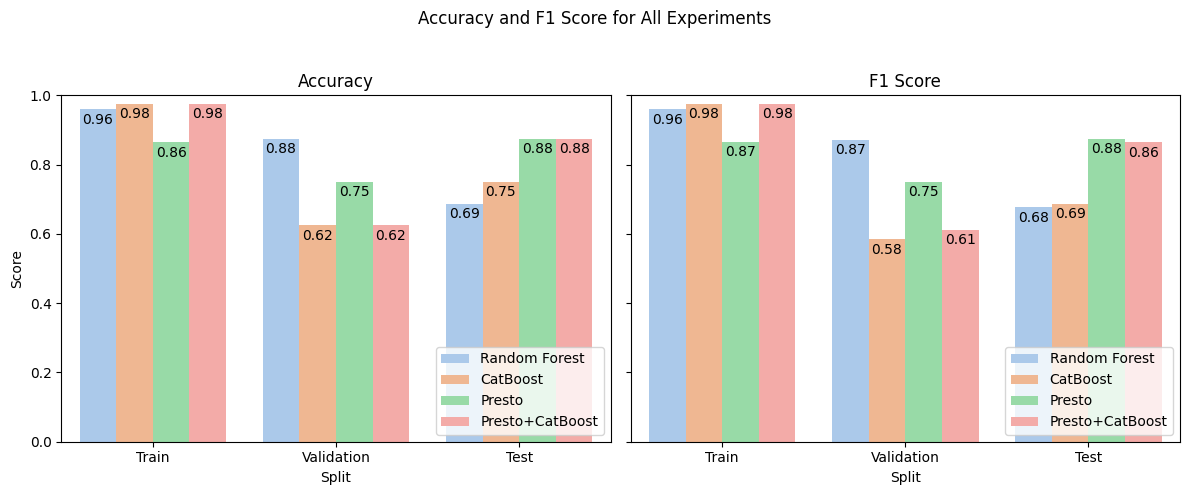

In [32]:
from sklearn.metrics import accuracy_score, f1_score

# Prepare predictions and labels for each experiment
experiments = {
    "Random Forest": (preds_train_rf, preds_val_rf, preds_test_rf),
    "CatBoost": (preds_train_cb, preds_val_cb, preds_test_cb),
    "Presto": (train_preds_presto, val_preds_presto, test_preds_presto),
    "Presto+CatBoost": (preds_train_presto_cb, preds_val_presto_cb, preds_test_presto_cb),
}

splits = [("Train", y_train), ("Validation", y_val), ("Test", y_test)]

metrics = []
for exp_name, (train_pred, val_pred, test_pred) in experiments.items():
    preds = [train_pred, val_pred, test_pred]
    for (split_name, y_true), y_pred in zip(splits, preds):
        # If predictions are torch tensors, convert to numpy
        if hasattr(y_pred, "detach"):
            y_pred = y_pred.detach().cpu().numpy()
        if hasattr(y_true, "values"):
            y_true = y_true.values
        # For Presto, predictions may be bool, convert to int
        y_pred = y_pred.astype(int)
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        metrics.append({
            "Experiment": exp_name,
            "Split": split_name,
            "Accuracy": acc,
            "F1 Score": f1_macro
        })

metrics_df = pd.DataFrame(metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for i, metric in enumerate(["Accuracy", "F1 Score"]):
    ax = axes[i]
    sns.barplot(
        data=metrics_df,
        x="Split",
        y=metric,
        hue="Experiment",
        ax=ax,
        palette="pastel"
    )
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.legend(loc="lower right")
    # Add numbers on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(f"{height:.2f}", 
                        (p.get_x() + p.get_width() / 2., height - 0.05), 
                        ha='center', va='bottom', fontsize=10, color='black', rotation=0)

plt.suptitle("Accuracy and F1 Score for All Experiments")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

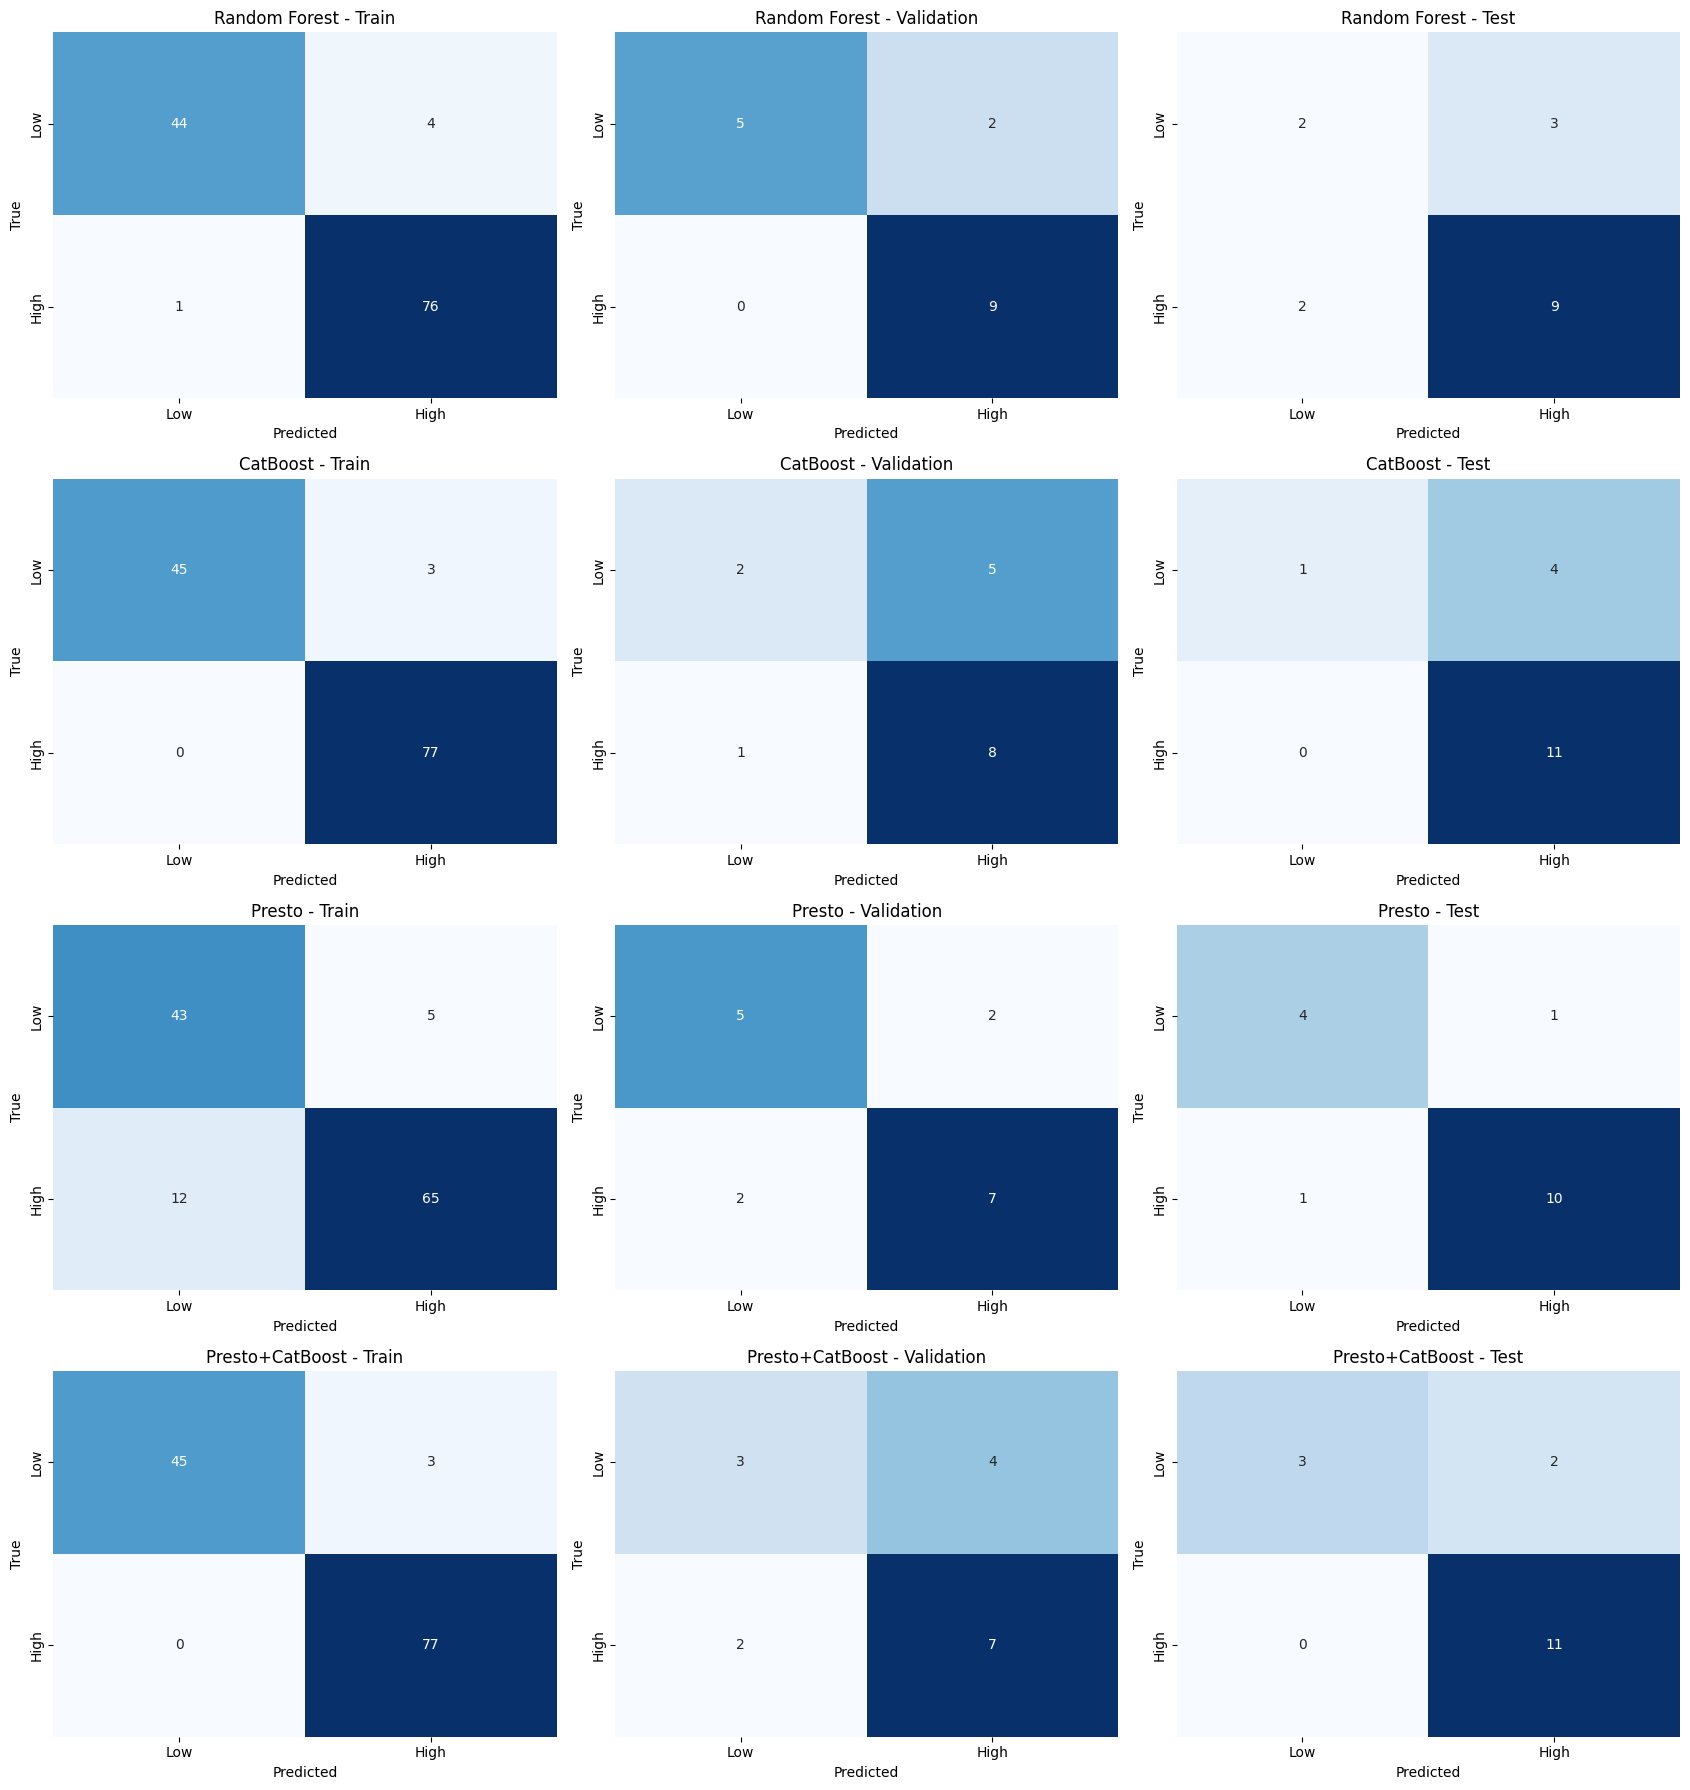

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare predictions and true labels for each model and split
model_names = ["Random Forest", "CatBoost", "Presto", "Presto+CatBoost"]
split_names = ["Train", "Validation", "Test"]
model_preds = [
    [preds_train_rf, preds_val_rf, preds_test_rf],
    [preds_train_cb, preds_val_cb, preds_test_cb],
    [train_preds_presto.astype(int), val_preds_presto.astype(int), test_preds_presto.astype(int)],
    [preds_train_presto_cb, preds_val_presto_cb, preds_test_presto_cb],
]
model_trues = [
    [y_train.values, y_val.values, y_test.values],
    [y_train.values, y_val.values, y_test.values],
    [train_targets_presto, val_targets_presto, test_targets_presto],
    [train_targets_presto, val_targets_presto, test_targets_presto],
]

fig, axes = plt.subplots(4, 3, figsize=(17, 18))

for row, model_name in enumerate(model_names):
    for col, split_name in enumerate(split_names):
        y_true = model_trues[row][col]
        y_pred = model_preds[row][col]
        # Convert boolean to int if needed
        if y_pred.dtype == bool:
            y_pred = y_pred.astype(int)
        if y_true.dtype == bool:
            y_true = y_true.astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row, col], cbar=False,
                    xticklabels=["Low", "High"], yticklabels=["Low", "High"])
        axes[row, col].set_xlabel('Predicted')
        axes[row, col].set_ylabel('True')
        axes[row, col].set_title(f"{model_name} - {split_name}")

plt.tight_layout()
plt.show()


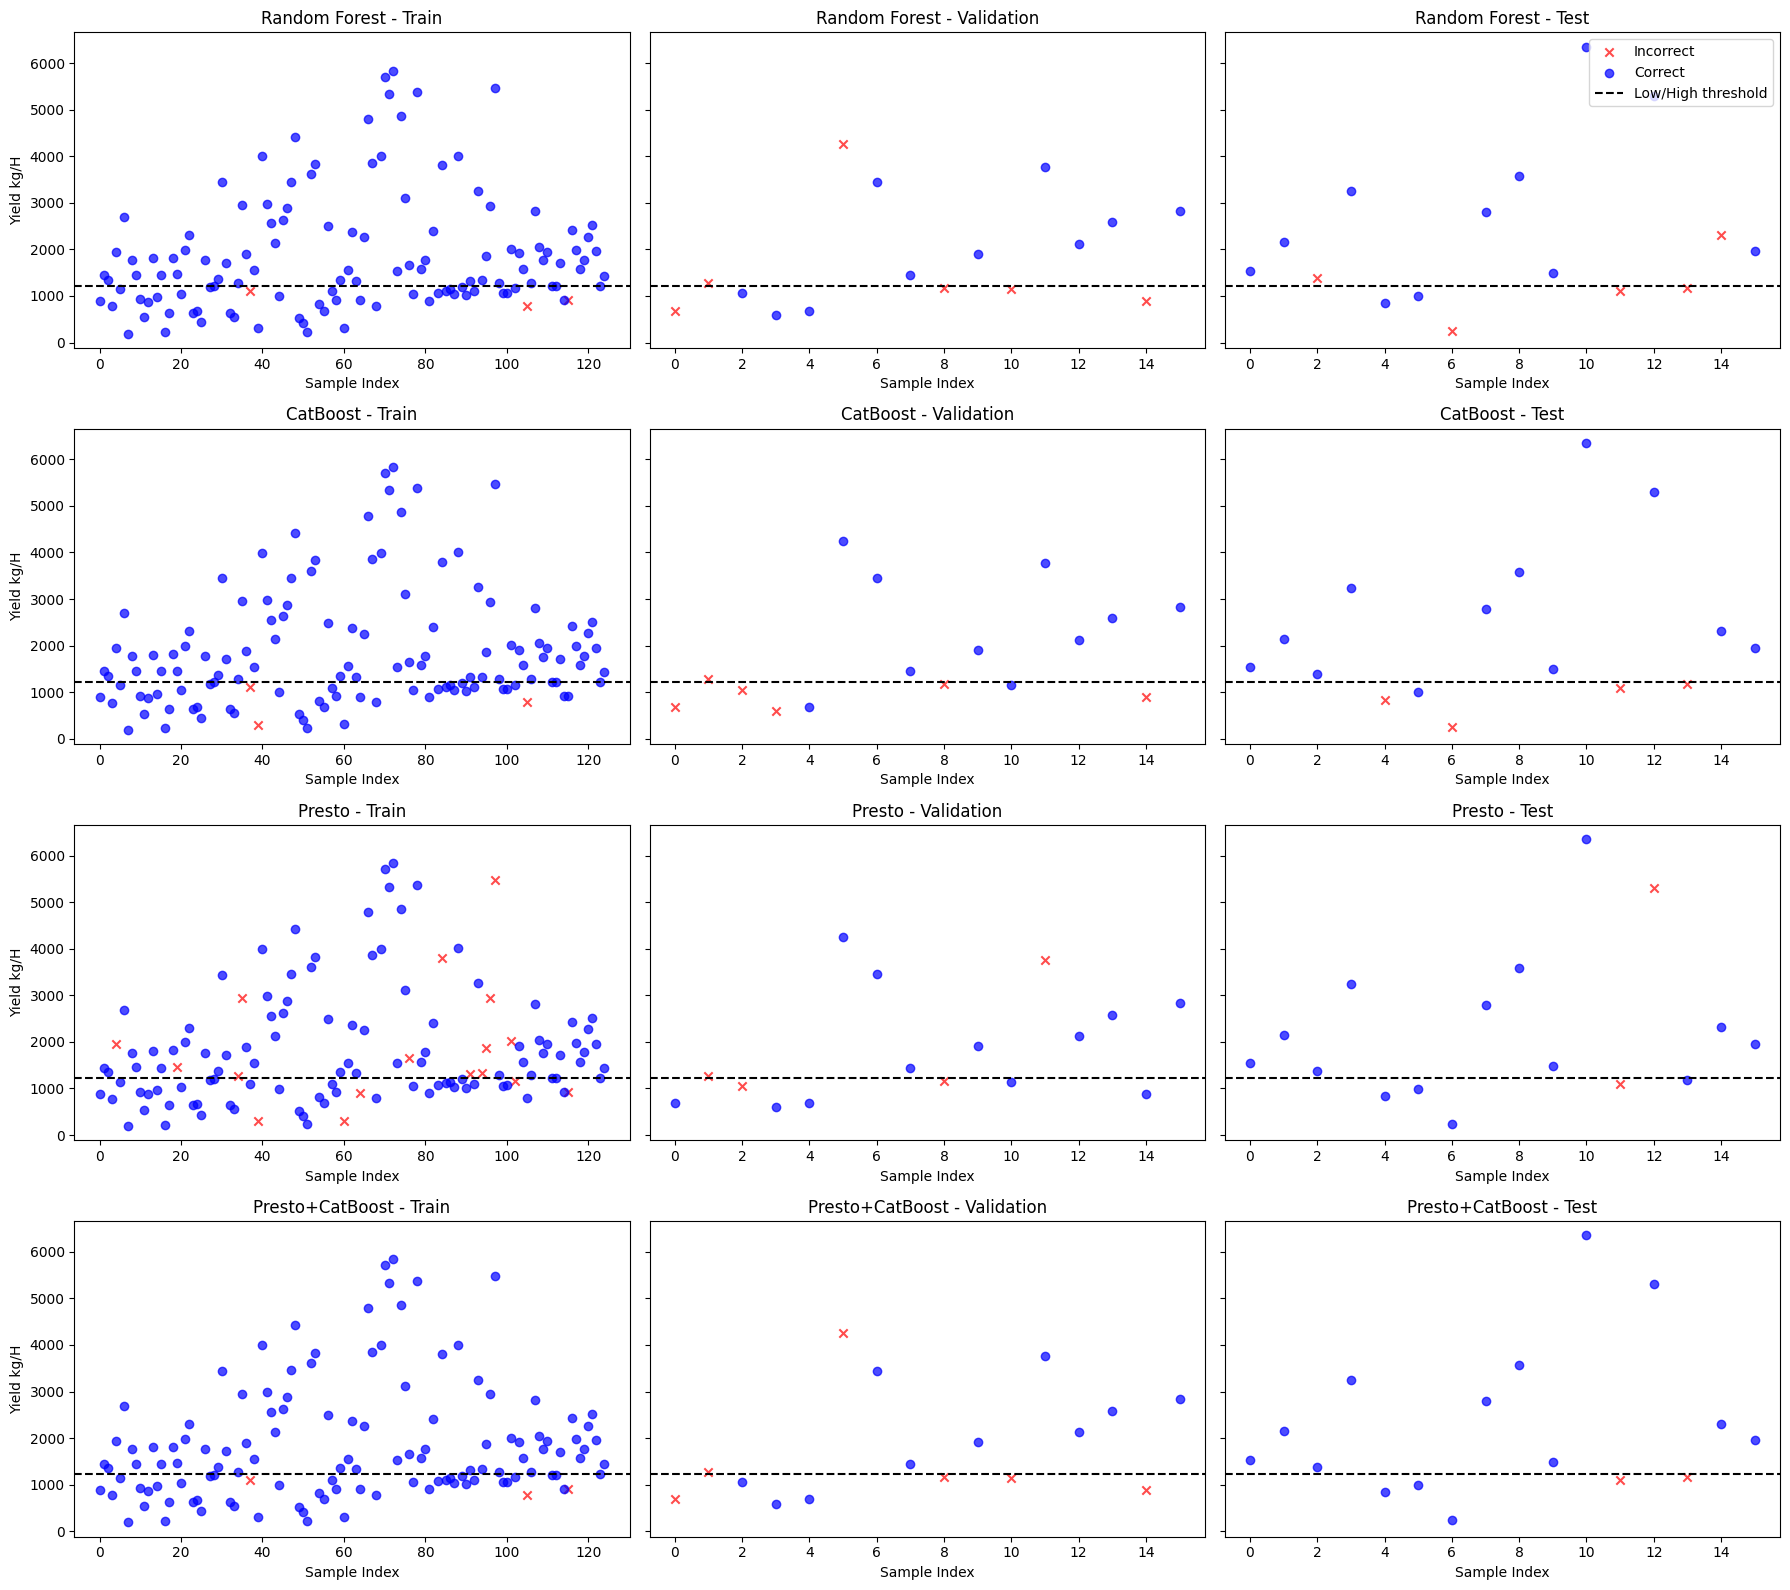

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for plotting
# Each entry: (Model Name, [y_true_train, y_true_val, y_true_test], [y_pred_train, y_pred_val, y_pred_test], [yields_train, yields_val, yields_test])
plot_data = [
    (
        "Random Forest",
        [y_train.values, y_val.values, y_test.values],
        [train_pred, val_pred, preds_test_rf],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
    (
        "CatBoost",
        [y_train.values, y_val.values, y_test.values],
        [preds_train_cb, preds_val_cb, preds_test_cb],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
    (
        "Presto",
        [train_targets_presto, val_targets_presto, test_targets_presto],
        [train_preds_presto.astype(int), val_preds_presto.astype(int), test_preds_presto.astype(int)],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
    (
        "Presto+CatBoost",
        [train_targets_presto, val_targets_presto, test_targets_presto],
        [preds_train_presto_cb, preds_val_presto_cb, preds_test_presto_cb],
        [train_df["Yield kg/H"].values, val_df["Yield kg/H"].values, test_df["Yield kg/H"].values],
    ),
]

col_titles = ["Train", "Validation", "Test"]

fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=False, sharey=True)

for row, (model_name, y_trues, y_preds, yields) in enumerate(plot_data):
    for col in range(3):
        ax = axes[row, col]
        y_true = y_trues[col]
        y_pred = y_preds[col]
        yield_vals = yields[col]
        correct = (y_true == y_pred)
        # Plot correct in blue, incorrect in red
        ax.scatter(
            np.arange(len(yield_vals))[~correct], yield_vals[~correct], 
            c="red", label="Incorrect", alpha=0.7, marker="x"
        )
        ax.scatter(
            np.arange(len(yield_vals))[correct], yield_vals[correct], 
            c="blue", label="Correct", alpha=0.7, marker="o"
        )
        # Draw the bin threshold line and always show its label in the legend
        ax.axhline(bin_th, color="black", linestyle="--", label="Low/High threshold")
        ax.set_title(f"{model_name} - {col_titles[col]}")
        ax.set_xlabel("Sample Index")
        if col == 0:
            ax.set_ylabel("Yield kg/H")
        if row == 0 and col == 2:
            ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

---

# GEOMaize — Binary Yield Classification: Results Report & Analysis

## 1. Setup Recap

**Task:** Binary classification of maize yield — *Low* (< 1220 kg/H) vs *High* (≥ 1220 kg/H) — using monthly composite satellite features (Sentinel-2, Sentinel-1, DEM, Meteorological) extracted July–November over Ghana.

**Dataset:** 157 field-year records from 4 seasons (2021–2025), split 80/10/10 stratified by class:

| Split | Total | Low (0) | High (1) |
|-------|-------|---------|---------|
| Train | 125 | 48 | 77 |
| Validation | 16 | 7 | 9 |
| Test | 16 | 5 | 11 |

---

## 2. Full Results from Actual Outputs

### 2.1 Accuracy and Weighted F1

From the bar chart outputs:

| Model | Train Acc | Val Acc | Test Acc | Train F1-w | Val F1-w | Test F1-w |
|-------|-----------|---------|----------|------------|----------|-----------|
| Random Forest | 0.96 | 0.88 | 0.69 | 0.96 | 0.87 | 0.68 |
| CatBoost | 0.98 | 0.62 | 0.75 | 0.98 | 0.58 | 0.69 |
| **Presto (fine-tuned)** | 0.86 | 0.75 | **0.88** | 0.87 | 0.75 | **0.88** |
| Presto + CatBoost | 0.98 | 0.62 | **0.88** | 0.98 | 0.61 | 0.86 |

### 2.2 Confusion Matrices — Test Set (derived from actual heatmap outputs)

**Random Forest — Test:**
|  | Pred. Low | Pred. High |
|--|-----------|------------|
| **True Low (5)** | 2 | 3 |
| **True High (11)** | 2 | 9 |

→ Low recall = 2/5 = **0.40** | High recall = 9/11 = **0.82** | Accuracy = 11/16 = **0.69**

**CatBoost — Test:**
|  | Pred. Low | Pred. High |
|--|-----------|------------|
| **True Low (5)** | 1 | 4 |
| **True High (11)** | 0 | 11 |

→ Low recall = 1/5 = **0.20** | High recall = 11/11 = **1.00** | Accuracy = 12/16 = **0.75**

**Presto (fine-tuned) — Test:**
|  | Pred. Low | Pred. High |
|--|-----------|------------|
| **True Low (5)** | 4 | 1 |
| **True High (11)** | 1 | 10 |

→ Low recall = 4/5 = **0.80** | High recall = 10/11 = **0.91** | Accuracy = 14/16 = **0.88**

**Presto + CatBoost — Test:**
|  | Pred. Low | Pred. High |
|--|-----------|------------|
| **True Low (5)** | 3 | 2 |
| **True High (11)** | 0 | 11 |

→ Low recall = 3/5 = **0.60** | High recall = 11/11 = **1.00** | Accuracy = 14/16 = **0.88**

### 2.3 Per-class test metrics (computed from confusion matrices)

| Model | Low Prec | Low Recall | Low F1 | High Prec | High Recall | High F1 | Macro F1 |
|-------|----------|-----------|--------|-----------|------------|---------|---------|
| RF | 0.50 | 0.40 | 0.44 | 0.75 | 0.82 | 0.78 | 0.61 |
| CatBoost | 1.00 | 0.20 | 0.33 | 0.73 | 1.00 | 0.85 | 0.59 |
| **Presto** | **0.80** | **0.80** | **0.80** | **0.91** | **0.91** | **0.91** | **0.85** |
| Presto+CB | 1.00 | 0.60 | 0.75 | 0.85 | 1.00 | 0.92 | 0.83 |

---

## 3. Analysis

### 3.1 Fine-tuned Presto is the best model overall

Presto achieves the **highest test accuracy (0.88)**, the **highest macro F1 (0.85)**, and critically, the **best balance between Low and High Yield detection** on the test set. It correctly identifies 4 out of 5 Low Yield fields (80% recall) while also correctly identifying 10 out of 11 High Yield fields (91% recall). This is the only model that achieves strong performance on *both* classes simultaneously.

The reason for Presto's advantage is fundamental: it processes the **full time series as an ordered sequence**, allowing the self-attention mechanism to capture temporal patterns across the growing season — greenup timing, peak NDVI, rate of senescence — that are meaningfully linked to final yield. Flat-feature models (RF, CatBoost) treat each month's bands as independent columns and must discover temporal relationships implicitly from co-occurrence statistics in 125 training samples, which is insufficient.

Presto also benefits from **large-scale pretraining** on WorldCereal EO data. Even with only 125 fine-tuning examples, the transformer already has a strong prior over crop phenology patterns, meaning fine-tuning only needs to adjust the final classification head and subtly shift the representation — a much lower-data regime than training from scratch.

### 3.2 Presto's train accuracy (0.86) reveals healthy generalisation

A key diagnostic: Presto's training accuracy is **0.86**, the lowest of all models. This is actually a *positive* sign. RF (0.96), CatBoost (0.98), and Presto+CB (0.98) all achieve near-perfect training accuracy, indicating they are memorising the training set. Presto, by contrast, retains some training error — it misclassifies 5 Low Yield examples as High and 12 High examples as Low on training data — which is consistent with a model that has learned a general decision boundary rather than memorised individual samples.

The train→test accuracy trajectory tells the story most clearly:

| Model | Train → Test | Gap |
|-------|-------------|-----|
| Random Forest | 0.96 → 0.69 | **−0.27** (severe overfitting) |
| CatBoost | 0.98 → 0.75 | **−0.23** (moderate overfitting) |
| Presto+CatBoost | 0.98 → 0.88 | **−0.10** (mild overfitting) |
| **Presto** | 0.86 → 0.88 | **+0.02** (no overfitting — slight improvement on test) |

Presto is the only model that does *not* overfit. Its test performance actually slightly exceeds training, which is unusual and may reflect the specific composition of this random split's test set (14/16 correct, vs 108/125 = 86.4% on train).

### 3.3 Random Forest: good on validation, bad on test

RF has the highest validation accuracy (0.88) but the lowest test accuracy (0.69). This apparent reversal is a warning sign of high variance from the tiny evaluation sets (16 samples each). The 0.88 validation score led the early-stopping loop to select a specific number of trees that happened to fit the 16 validation examples well, but this advantage did not transfer to the 16 test examples. With a 4×4 confusion matrix, any two misclassifications change accuracy by 12.5%.

On the test set, RF misclassifies 3 of 5 Low Yield fields (Low recall = 0.40) and 2 of 11 High Yield fields, producing an unbalanced result. This reflects the lack of class weighting: with no `class_weight='balanced'`, tree splits are dominated by the majority class examples.

### 3.4 CatBoost: high precision on Low Yield, extremely low recall

CatBoost's test confusion matrix is striking: it correctly identifies only **1 of 5 Low Yield fields** (20% recall) but with perfect precision (1.00 — the only Low Yield prediction it makes is correct). CatBoost has learned a very conservative Low Yield rule — it only labels a field Low when it is very confident. This is a symptom of class imbalance without compensation: the gradient signal is dominated by the 77 High Yield examples, pushing the decision boundary deep into Low Yield territory. On the validation set, CatBoost already shows this pattern (only 2/7 Low Yield correct, dropping further to 1/5 on test), confirming this is a systematic bias rather than bad luck.

On the other hand, CatBoost perfectly captures all High Yield fields on the test set (11/11), making it useful if the priority is to avoid false Low alarms — but harmful if the goal is to flag at-risk low-yield fields for intervention.

### 3.5 Presto + CatBoost: very good, especially for High Yield

Presto+CatBoost achieves the same test accuracy as fine-tuned Presto (0.88) and perfect High Yield recall (11/11), but is less balanced: it catches only 3/5 Low Yield fields (vs Presto's 4/5). It has the advantage of never predicting a false Low for High Yield fields (0 false positives on High), giving it perfect High precision. This makes it particularly reliable when you need to be certain that a "High Yield" prediction will be correct.

The comparison between Presto (fine-tuned) and Presto+CatBoost illustrates the trade-off between end-to-end learning and feature-extraction + shallow classifier:
- Fine-tuning the full backbone allows the model to adapt representations specifically to yield prediction, improving Low Yield detection (4/5 vs 3/5).
- The frozen encoder + CatBoost setup is more conservative with Low Yield predictions, making fewer errors on High Yield at the cost of missing some Low Yield fields.

---

## 4. Limitations

**Tiny test set.** With only 16 test samples (5 Low, 11 High), every number in the confusion matrix represents ~6% of accuracy. The difference between Presto (0.88) and CatBoost (0.75) on the test set is literally 2 correctly classified fields. These results are directional, not statistically conclusive.

**Single split (random_state=42).** The particular 16 samples in the test fold heavily influence all conclusions. Different seeds will produce different test compositions and could meaningfully change the ranking.

**No class weighting.** The `pos_weight` parameter in `BCEWithLogitsLoss` is commented out. Enabling it with `pos_weight = n_Low / n_High = 48/77 ≈ 0.62` would push Presto to predict Low even more aggressively, potentially further improving Low Yield recall at a small cost to High Yield precision.

**Inter-annual variability.** The four seasons span very different yield ranges (2021 min=190 vs 2023 min=901 kg/H). Pooling without domain-shift correction means the 1220 kg/H threshold captures very different proportions of each year's distribution.

**Spatial autocorrelation.** Physical fields appearing in multiple seasons share location, soil, and microclimate. Even with year-suffixed IDs, the train and test sets are not spatially independent.

---

## 5. Conclusions and Next Steps

**Presto fine-tuning is the recommended approach** for this dataset. It achieves the best overall accuracy (88%), the best macro F1 (0.85), and the most balanced detection of both low- and high-yield fields — with virtually no overfitting. The pretrained backbone's crop phenology knowledge transfers effectively to the Ghana maize yield task even with only 125 training examples.

**Immediate improvements to test:**
1. **Enable `pos_weight`** in the BCE loss — this is a one-line change expected to push Low Yield recall above 0.80 while maintaining High Yield performance.
2. **Evaluate with Leave-One-Year-Out CV** to get a distribution of performance estimates across folds and confirm that the 0.88 test accuracy holds across different year combinations.
3. **Test the `ReduceLROnPlateau` scheduler** (already scaffolded in the code) — a decaying LR may help Presto converge to a sharper decision boundary.
4. **Collect more Low Yield labelled data** — with only 48 Low Yield training examples, the decision boundary in Low Yield territory is constrained. Even 20–30 additional Low Yield examples from 2024 or another season would meaningfully improve stability.
